# Импорты

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Объединяем файлы
В папках part_* лежат файлы csv и parquet которые представляют из себя кусочки тренировчного датасета. перед началом работы нужно все эти файлы собрать в один для этого рекурсивным поиском найдем все файлы форматов .csv и .parquet, которые начинаются на "data_part_". 

In [152]:

root = Path.cwd() # расположение папок
out = Path("all_data.csv") # итоговый соединенный файл

csv_files = sorted(root.rglob("data_part_*.csv"))
parquet_files = sorted(root.rglob("data_part_*.parquet"))
first = True # флаг для названия столбцов
columns_ref = None  

def write_chunk(df):
    global first, columns_ref

    if columns_ref is None:
        columns_ref = df.columns # устанавливаем первый полученный порядок столбцов как эталонный
    else:
        # выравниваем колонки по эталону
        df = df.reindex(columns=columns_ref)

    df.to_csv(out, mode="w" if first else "a", index=False, header=first) # мод w - перезаписываем(только первое), для остальных мод "a" (дописывать снизу)
    first = False


# соединяем csv файлы
for f in csv_files: 
    df = pd.read_csv(f)
    if df.empty:
        continue
    write_chunk(df)


# соединяем parquet файлы
for f in parquet_files:
    dfp = pd.read_parquet(f)
    if dfp.empty:
        continue
    write_chunk(dfp)


После склейки получилось 7161 строка

In [4]:
df = pd.read_csv("all_data.csv")
df.head(100)

,Год_рождения,Подписаны_документы,Пол,БылПростой,ОпытВДолжности,Активность,Знак_зодиака,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Телефон,Город,Размер,Закрытые_проекты,ГодНайма,Курсы,Увольнение
0,1993.0,Нет,NaN,NaN,0.0,NaN,Овен,34.0,1.0,3.0,0.0,Bachelors,917107113682,Bangalore,NaN,8.0,2017.0,3.0,0
1,1997.0,Да,Female,NaN,NaN,NaN,Рыбы,28.0,2.0,1.0,0.0,Bachelors,911237763698,Pune,M,5.0,NaN,2.0,1
2,1997.0,Да,Female,No,3.0,87.0,Рыбы,NaN,2.0,1.0,0.0,Bachelors,911237763698,Pune,M,5.0,2013.0,2.0,1
3,1989.0,Нет,Female,No,2.0,296.0,Козерог,38.0,10.0,3.0,0.0,NaN,919854642062,New Delhi,XS,14.0,NaN,2.0,0
4,1989.0,Нет,NaN,No,2.0,296.0,Козерог,38.0,10.0,3.0,0.0,NaN,919854642062,New Delhi,XS,14.0,2014.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2000.0,Да,Male,No,4.0,65.0,Лев,26.0,2.0,3.0,0.0,Bachelors,913854211673,Bangalore,M,7.0,2018.0,NaN,1
96,NaN,Да,Male,NaN,4.0,65.0,Лев,NaN,2.0,3.0,0.0,NaN,913854211673,Bangalore,M,7.0,2018.0,NaN,1
97,1986.0,Нет,Male,No,5.0,73.0,NaN,40.0,7.0,NaN,0.0,Bachelors,916964586296,Bangalore,S,NaN,NaN,3.0,0
98,1986.0,Нет,Male,No,5.0,73.0,Козерог,NaN,7.0,3.0,0.0,Bachelors,916964586296,Bangalore,S,15.0,2016.0,3.0,0


# Фильтрация данных

## Предварительный анализ

##### Сколько пустых в каждом столбце

In [5]:
df.isna().sum()

Год_рождения           1401
Подписаны_документы    1417
Пол                    1448
БылПростой             1404
ОпытВДолжности         1447
Активность             1407
Знак_зодиака           1463
Возраст                1436
Оценка_HR              1423
УровеньОплаты          1442
Офлайн_участие         1414
Образование            1464
Телефон                   0
Город                  1476
Размер                 1422
Закрытые_проекты       1404
ГодНайма               1426
Курсы                  1457
Увольнение                0
dtype: int64

#### Сколько процентов пустых в каждом столбце

In [6]:
(df.isna().mean() * 100).sort_values(ascending=False)

Город                  20.611646
Образование            20.444072
Знак_зодиака           20.430108
Курсы                  20.346320
Пол                    20.220640
ОпытВДолжности         20.206675
УровеньОплаты          20.136852
Возраст                20.053065
ГодНайма               19.913420
Оценка_HR              19.871526
Размер                 19.857562
Подписаны_документы    19.787739
Офлайн_участие         19.745846
Активность             19.648094
БылПростой             19.606200
Закрытые_проекты       19.606200
Год_рождения           19.564307
Телефон                 0.000000
Увольнение              0.000000
dtype: float64

Почти во всех столбцах кроме "Телефон" и "Увольнение" 20% пустот. т.к. "Увольнение" является нашей целевой переменной, то среди оставшихся столбцов выделяется только "Телефон". Проверим уникальность его значений.


#### Анализ столбца "Телефон"

In [7]:
print(df.nunique())
print(df.shape)

Год_рождения             22
Подписаны_документы       2
Пол                       2
БылПростой                2
ОпытВДолжности            8
Активность              495
Знак_зодиака             12
Возраст                  20
Оценка_HR                11
УровеньОплаты             3
Офлайн_участие            2
Образование               3
Телефон                2381
Город                     3
Размер                    6
Закрытые_проекты         16
ГодНайма                  7
Курсы                     5
Увольнение                2
dtype: int64
(7161, 19)


из 7161 записей уникальных телефонов всего 2381. Посмотрим на них.

In [8]:
df[df.duplicated(subset=["Телефон"], keep=False)]



,Год_рождения,Подписаны_документы,Пол,БылПростой,ОпытВДолжности,Активность,Знак_зодиака,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Телефон,Город,Размер,Закрытые_проекты,ГодНайма,Курсы,Увольнение
1,1997.0,Да,Female,NaN,NaN,NaN,Рыбы,28.0,2.0,1.0,0.0,Bachelors,911237763698,Pune,M,5.0,NaN,2.0,1
2,1997.0,Да,Female,No,3.0,87.0,Рыбы,NaN,2.0,1.0,0.0,Bachelors,911237763698,Pune,M,5.0,2013.0,2.0,1
3,1989.0,Нет,Female,No,2.0,296.0,Козерог,38.0,10.0,3.0,0.0,NaN,919854642062,New Delhi,XS,14.0,NaN,2.0,0
4,1989.0,Нет,NaN,No,2.0,296.0,Козерог,38.0,10.0,3.0,0.0,NaN,919854642062,New Delhi,XS,14.0,2014.0,2.0,0
5,1989.0,NaN,Female,NaN,2.0,296.0,Козерог,38.0,10.0,3.0,0.0,Bachelors,919854642062,New Delhi,XS,14.0,2014.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7156,1991.0,NaN,Female,No,1.0,494.0,Лев,36.0,3.0,NaN,1.0,Bachelors,919128780946,NaN,M,2.0,NaN,4.0,0
7157,1991.0,Нет,Female,No,1.0,NaN,Лев,36.0,3.0,1.0,NaN,Bachelors,919128780946,Bangalore,M,2.0,2014.0,NaN,0
7158,1991.0,NaN,Female,No,1.0,494.0,Лев,36.0,3.0,1.0,NaN,Bachelors,919128780946,NaN,M,2.0,2014.0,NaN,0
7159,1987.0,Нет,Male,No,NaN,444.0,Овен,NaN,8.0,3.0,NaN,Bachelors,919238580738,Bangalore,S,12.0,2017.0,1.0,0


При анализе дубликатов можно заметить что одинаковые не только номера телефонов, но и большая часть строки, разве что в некоторых местах возникают NaN вместо данных. Соединим дубликаты, чтобы оставить как можно меньше NaN

In [9]:
df = df.groupby("Телефон", as_index=False).first()

Посмотрим теперь на количество оставшихся ячеек и количество уникальных значений номеров телефонов

In [10]:
print(df.nunique())
print(df.shape)

Телефон                2381
Год_рождения             22
Подписаны_документы       2
Пол                       2
БылПростой                2
ОпытВДолжности            8
Активность              495
Знак_зодиака             12
Возраст                  20
Оценка_HR                11
УровеньОплаты             3
Офлайн_участие            2
Образование               3
Город                     3
Размер                    6
Закрытые_проекты         16
ГодНайма                  7
Курсы                     5
Увольнение                2
dtype: int64
(2381, 19)


Более 5000 значений были просто дубликатами, теперь EDA гораздо чище и можно приступать к анализу непосредственно пустых ячеек

#### Устранение NaN. Part 1

Посмотрим сколько строчек с разным количеством пустот

In [11]:
df.isna().sum(axis=1).value_counts().sort_index()

0     1616
1      270
2      150
3      127
4      111
5       57
6       26
7       19
8        4
10       1
Name: count, dtype: int64

Как видно выше у нас есть строки где много пустых ячеек, такие строки могут портить выборку и путать модель, поэтому удалим строки где 6 и более пустых ячеек. 

In [12]:
df = df[df.isna().sum(axis=1) < 6]

In [13]:
print(df.nunique())
print(df.shape)

Телефон                2331
Год_рождения             22
Подписаны_документы       2
Пол                       2
БылПростой                2
ОпытВДолжности            8
Активность              495
Знак_зодиака             12
Возраст                  20
Оценка_HR                11
УровеньОплаты             3
Офлайн_участие            2
Образование               3
Город                     3
Размер                    6
Закрытые_проекты         16
ГодНайма                  7
Курсы                     5
Увольнение                2
dtype: int64
(2331, 19)


Было удалено около 2% всех строк, это не критично, если учитывать факт что там треть ячеек были пустыми. Тем не менее осталось еще много пустых ячеек, разберемся с ними после того как узнаем какие из признаков нам нужны, а какие не очень.

### Связи между признаками

В ходе тестирования модели была замечена связь между колонками "Подписаны_документы" и "Увольнение". Также в выборке X_test.csv, которая пойдет в codabench, этот столбец вовсе пуст, поэтому обучению от скорее всего навредит.

In [14]:
print("Всего строк:", df.shape)
count = df[
    ((df["Подписаны_документы"] == "Да") & (df["Увольнение"] == 1)) |
    ((df["Подписаны_документы"] == "Нет") & (df["Увольнение"] == 0))
].shape[0]

print("Количество совпадающих строк:", count)

Всего строк: (2331, 19)
Количество совпадающих строк: 2210


в 94% случаев столбец "Подписаны_документы" совпадает по смыслу со столбцом "Увольнение". Если оставить этот признак то на train и test данные roc_auc будет 0.99+, при этом на codabench выдает всего 0.74. Удалим этот столбец.

In [15]:
df = df.drop(columns=["Подписаны_документы"])

##### Категориальные признаки

##### χ²-тест
Тесты χ² помогают определить, есть ли между категориальными столбцами статистически значимая связь. В данном случае будем искать связь столбца "Увольнение" с остальными. Если p < 0.05, то связь между целевой переменной и признаком есть, иначе связи нет.

In [16]:
features = [c for c in df.columns if c != "Увольнение"]
cat_cols = df.select_dtypes(include="str").columns.tolist()
results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df["Увольнение"])
    chi2, p, dof, exp = chi2_contingency(table)
    results.append((col, p))

res_df = pd.DataFrame(results, columns=["feature", "p_value"])
res_df = res_df.sort_values("p_value")
res_df

,feature,p_value
0,Пол,3.982441e-20
4,Город,2.080247e-12
3,Образование,4.946934e-06
5,Размер,5.148434e-03
1,БылПростой,3.843576e-02
2,Знак_зодиака,4.865924e-01


Целевая переменная имеет статистически значимую связь со всеми признаками кроме "Знак_зодиака" => его можно удалить.


In [17]:
df = df.drop(columns=["Знак_зодиака"])

##### Числовые признаки

Составим корреляционную матрицу для проверки зависимостей всех числовых признаков

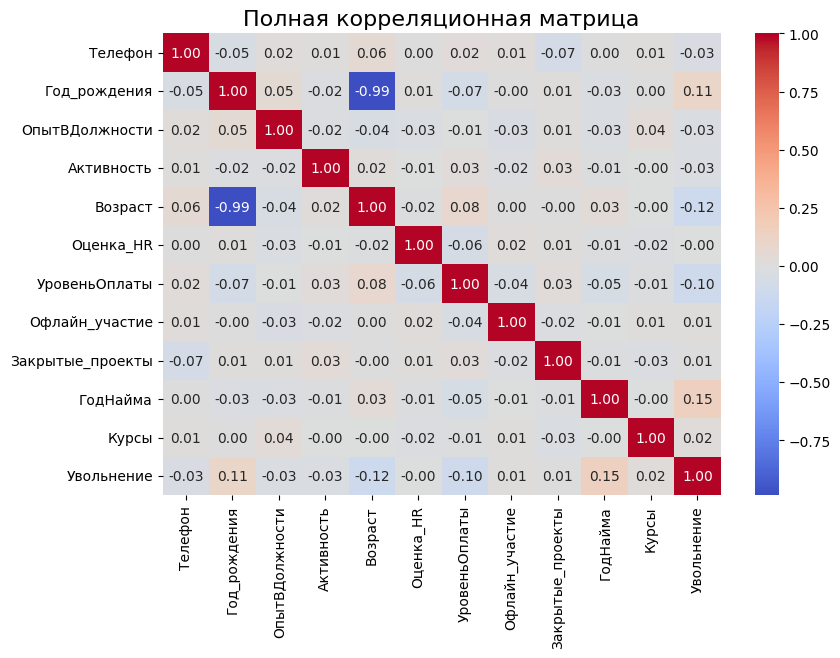

In [18]:

corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Полная корреляционная матрица", fontsize=16)
plt.show()

Можно заметить только связь между "Возраст" и "Год_рождения", у остальных признаков связь около 0. Удалим "Год_рождения".

In [19]:
df = df.drop(columns=["Год_рождения"]) 

Признак "Телефон" уникален для каждой строки, т.е. по своей сути, он выступает как ID сотрудника, для модели ID не важен.

In [20]:
df = df.drop(columns=["Телефон"]) 

#### Выбросы
Оставшиеся признаки стоит проверить на наличие выбросов. Т.к. большая часть числовых признаков имеет около 2-8 уникальных значений, выбросов в них скорее всего не будет, стоит проверить только  "Активность"(495 уникальных) и "Возраст"(20 уникальных) и "Закрытые_проекты"(16 уникальных).

In [21]:
df.describe()

,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Закрытые_проекты,ГодНайма,Курсы,Увольнение
count,2208.000000,2244.000000,2232.000000,2222.000000,2237.000000,2247.000000,2224.000000,2239.000000,2238.000000,2331.000000
mean,2.631793,254.016488,31.192652,4.961746,2.629414,0.506898,7.542266,2015.111210,2.553172,0.390390
std,1.613217,145.107967,5.111801,3.151420,0.628691,0.500064,4.515183,1.883007,1.317190,0.487942
min,0.000000,0.000000,22.000000,0.000000,1.000000,0.000000,0.000000,2012.000000,1.000000,0.000000
25%,1.000000,127.000000,27.000000,2.000000,2.000000,0.000000,4.000000,2014.000000,1.000000,0.000000
50%,2.000000,260.000000,30.000000,5.000000,3.000000,1.000000,7.000000,2015.000000,2.000000,0.000000
75%,4.000000,374.000000,36.000000,8.000000,3.000000,1.000000,11.000000,2017.000000,3.000000,1.000000
max,7.000000,500.000000,41.000000,10.000000,3.000000,1.000000,15.000000,2018.000000,5.000000,1.000000


##### Активность
При 495 уникальных значениях min = 0 и max = 500 выглядят нормально.
##### Возраст
min = 22 и max = 41 тоже выглядит нормально
#####  Закрытые проекты
Всего 16 уникальных значений, min = 0, max = 15 => всё нормально.

#### Устранение NaN. Part 2
Теперь, после того как мы разобрались с числовыми и категориальными признаками можно устранять оставшиеся NaN значения.

In [22]:
df.isna().sum()

Пол                  98
БылПростой          107
ОпытВДолжности      123
Активность           87
Возраст              99
Оценка_HR           109
УровеньОплаты        94
Офлайн_участие       84
Образование         110
Город                95
Размер               94
Закрытые_проекты    107
ГодНайма             92
Курсы                93
Увольнение            0
dtype: int64

Категориальные признаки можно заполнить модой, а числовые средним значением, т.к. выбросов не наблюдается.

In [23]:
cat_cols = df.select_dtypes(include="str").columns.tolist() #категориальные
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
num_cols = df.select_dtypes(include=[np.number]) #числовые
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())
df.isna().sum()

Пол                 0
БылПростой          0
ОпытВДолжности      0
Активность          0
Возраст             0
Оценка_HR           0
УровеньОплаты       0
Офлайн_участие      0
Образование         0
Город               0
Размер              0
Закрытые_проекты    0
ГодНайма            0
Курсы               0
Увольнение          0
dtype: int64

In [24]:
print(df.shape)
df

(2331, 15)


,Пол,БылПростой,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Город,Размер,Закрытые_проекты,ГодНайма,Курсы,Увольнение
0,Male,Yes,0.0,474.0,28.0,2.0,3.000000,0.0,Bachelors,Bangalore,S,15.0,2016.0,5.000000,0
1,Male,No,1.0,28.0,29.0,0.0,3.000000,0.0,Masters,New Delhi,L,4.0,2014.0,2.553172,0
2,Female,No,0.0,164.0,39.0,3.0,2.000000,0.0,Bachelors,Bangalore,S,14.0,2015.0,1.000000,1
3,Male,No,4.0,372.0,30.0,10.0,1.000000,0.0,Bachelors,Bangalore,S,14.0,2016.0,4.000000,1
4,Female,No,2.0,314.0,35.0,3.0,3.000000,1.0,Bachelors,Bangalore,M,1.0,2014.0,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,Male,Yes,2.0,62.0,32.0,10.0,2.000000,0.0,Masters,New Delhi,L,9.0,2013.0,2.000000,1
2377,Female,Yes,5.0,474.0,27.0,3.0,2.629414,1.0,Bachelors,New Delhi,M,8.0,2015.0,2.000000,1
2378,Male,No,5.0,245.0,27.0,3.0,3.000000,1.0,Bachelors,New Delhi,L,1.0,2014.0,3.000000,0
2379,Male,No,3.0,327.0,39.0,4.0,3.000000,0.0,Bachelors,Pune,S,7.0,2015.0,3.000000,0


Итоговая EDA имеет 2331 строк, 15 столбцов и 0 пустых ячеек

#### Дисбаланс классов

In [25]:
print(df["Увольнение"].value_counts())
print(df["Увольнение"].value_counts(normalize=True) * 100)

Увольнение
0    1421
1     910
Name: count, dtype: int64
Увольнение
0    60.960961
1    39.039039
Name: proportion, dtype: float64


На "Увольнение" = 0 приходится 60% датасета, а на "увольнение" = 1 - 40%. В целом Датасет можно считать сбалансированным.

## Модель

In [26]:

# Разделяем X и y
X = df.drop(columns=["Увольнение"])
y = df["Увольнение"]

# Категориальные признаки
cat_features = X.select_dtypes(include="str").columns.tolist()

# Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Подбор гиперпараметров

С вручными подобранными гиперпараметрами(lr, iter, depth) результаты были порядка 0.87 на тренировочной выборке и 0.81 на тестовой. Чтобы не перебирать вручную все возможные их комбинации, я реализовал подбор гиперпараметров, где лучшими по итогу оказались iterations = 400, depth = 7 и lr = 0.2. После это результаты на тренировчной 0.91, а на тестовой 0.83. Также позже вручную подобрал параметр регуляризации l2_leaf_reg = 10, увеличив результаты до 0.97 и 0.84 соотвественно. При этом сейчас на codabench выдается результат 0.93. такую большую разницу между тестом и codabench можно попробовать объяснить не совсем удачным рандомом распределения, но всё же это показывает что модель в итоге обучилась хорошо.

In [27]:
# train_pool = Pool(
#     X_train,
#     y_train,
#     cat_features=cat_features
# )

# model = CatBoostClassifier(
#     loss_function="Logloss",
#     eval_metric="AUC",
#     l2_leaf_reg=10,
#     auto_class_weights="Balanced",
#     random_seed=42,
#     verbose=False
# )

# param_grid = {
#     "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.3],
#     "iterations": [400, 600, 800, 1000, 1200, 1400],
#     "depth": [1, 2, 3, 4, 6, 7, 8, 10]
# }

# search_result = model.grid_search(
#     param_grid,
#     train_pool,
#     cv=3,
#     shuffle=True,
#     stratified=True,
#     plot=False
# )

# print("Результат grid_search:")
# print(search_result)

In [28]:
# Модель
model = CatBoostClassifier(
    iterations=400, # максимальное количество построенных деревьев
    depth=7, # глубина дерева
    learning_rate=0.2, # скорость обучения
    loss_function="Logloss",
    eval_metric="AUC",
    l2_leaf_reg=10,        # регуляризация
    verbose=100,
)

model.fit(
    X_train, y_train, #выборка для обучения
    cat_features=[c for c in cat_features ],
    eval_set=(X_test, y_test),
    use_best_model=True,
)

# Оценка
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


0:	test: 0.7458550	best: 0.7458550 (0)	total: 165ms	remaining: 1m 5s
100:	test: 0.8368807	best: 0.8385965 (96)	total: 1.47s	remaining: 4.35s
200:	test: 0.8378832	best: 0.8426644 (111)	total: 2.68s	remaining: 2.66s
300:	test: 0.8371313	best: 0.8426644 (111)	total: 3.86s	remaining: 1.27s
399:	test: 0.8389435	best: 0.8426644 (111)	total: 5.01s	remaining: 0us

bestTest = 0.8426643532
bestIteration = 111

Shrink model to first 112 iterations.
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       285
           1       0.86      0.56      0.68       182

    accuracy                           0.79       467
   macro avg       0.81      0.75      0.76       467
weighted avg       0.80      0.79      0.78       467

ROC AUC: 0.842664353190669


#### Train и Test
Точность тренировочной выборки составляет 0.97

Точность тестовой выборки составляет 0.84

Точность codabench выборки составляет 0.93

Модель показывает хорошие результаты на внешних данных. Предположу, что отличие тестовой и codabench выборок происходят из-за малого размера тестовой выборки.

In [29]:
print("Train AUC:", roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))
print("Test AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


Train AUC: 0.9761054306608884
Test AUC: 0.842664353190669


Формируем пробу, создаем файл submission.csv

In [31]:

train = X.columns.tolist()
train_cat_features = cat_features[:]

X_new = pd.read_csv("X_test.csv")
X_new = X_new.reindex(columns=train)

proba = model.predict_proba(X_new)[:, 1]
pd.DataFrame({"proba": proba}).to_csv("submission.csv", index=False)

## Выводы

1. EDA
    1. Был проведен тщательный анализ данных, разбросанные таблицы были соединены в одну.
    2. Из итоговой выборки были удалены столбцы "Подписаны_доументы", "Телефон", "Знак_зодиака"  и "Год_рождения", так как не несли полезной информации для модели или даже ухудшали её результаты.
    3. Представленные данные содержали много дубликатов и пустых ячеек. Дубликаты были соединены в одну строку, пустые ячейки заполнялись модой(категориальные) и медианой(числовые).
    4. Выбросов в тренировочном датасете не было.
    5. Дисбаланс классов был в приемлемом соотношении (60/40).
2. Модель
    1. Датасет был разбит в соотношении train/test = 80/20
    2. Была выбрана модель CatBoost, так как хорошо работает с категориальными признаками и не требует их кодирования.
    3. Был реализован подбор гиперпараметров.
    4. Регуляризация была подобрана вручную и равна 10.
    5. В качестве метрики качества использовалась ROC-AUC.
    6. Полученные результаты:

    
        Обучающая выборка: 0.97


        Тестовая выборка: 0.85


        Codabench: 0.93


Интенсив как формат работы мне очень понравился. Лекции было интересно слушать, узнал оттуда много нового. Практики тоже были полезны, разговоры с куратором направляли в нужное русло.